In [28]:
"""
=============================================================================
PROJECT 1: E-Commerce Product Price Tracker & Analysis
=============================================================================
📌 Skills: Web Scraping, Data Cleaning, Statistical Analysis, Visualization
📌 Modules: requests, BeautifulSoup, pandas, numpy, matplotlib, seaborn
📌 CV Line: "Built an e-commerce price tracker that scrapes product data,
            performs statistical analysis, and generates visual dashboards"
=============================================================================
"""

import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
# STEP 1: WEB SCRAPING - Scrape Product Data
# ─────────────────────────────────────────────

def scrape_fake_store_api():
    '''Scrapping Products From FakeStoreAPI(free, no auth needed)'''
    print(f"🔍 Scrapping Products Data From FakeStoreApi....")

    url = "https://fakestoreapi.com/products"
    response = requests.get(url)

    if response.status_code == 200:
        products = response.json()
        print(f"✅Sucessfully Scraped the data of {len(products)} products!")
        return products
    else:
        print(f"❌Failed to Scraped Status Code :{response.status_code}")
        return []
        
def scrape_books_fakestoreapi():
    '''Scrape The Book Data From books.toscrape.com(designed for practice scraping)'''
    print("\n🔍 Scrape The Book Data From books.toscrape.com...")

    headers = {"User-Agent":
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"}

    books = []
    for page in range(1,4): #Scrape first 3 pages..
        url = f"https://books.toscrape.com/catalogue/page-{page}.html"
        response = requests.get(url, headers = headers)

        soup = BeautifulSoup(response.text,"html.parser")
        products_name = soup.find_all("article", class_ = "product_pod") 

        for products in products_name:
            title = products.h3.a["title"]
            price = products.find("p", class_ = "price_color").text.split("£")[1]
            rating = products.select_one("p.star-rating")["class"][1]
            stocks = products.find("p",class_ = "instock availability").text.strip()

            rating_map = {"One":1, "Two":2, "Three":3, "Four":4, "Five":5}

            books.append({
                "title": title,
                "price": float(price),
                "rating": rating_map.get(rating, 0),
                "in Stock": stocks
            })

        time.sleep(0.5) # Be polite with requests
        
    print(f"✅Scuessfully scraped {len(books)} products...")
    return books

# ─────────────────────────────────────────────
# STEP 2: DATA PROCESSING with Pandas & NumPy
# ─────────────────────────────────────────────

def process_products_data(products):
    '''Clean and Process the scrape products using Numpy and Pandas'''
    print("\n📊 Processing The Data...")

    df = pd.DataFrame(products)

    #Pandas operations...
    print(f"\n📝 Data Shape:{df.shape}")
    print(f"\n📝 Data Type:\n{df.dtypes}")
    print(f"\n📝 Missing Values:\n{df.isnull().sum()}")

    #Exact and Clean Data...
    if "rating" in df.columns and isinstance(df["rating"].iloc[0],dict):
        df["rating_score"] = df["rating"].apply(lambda x: x.get("rate",0) if isinstance(x,dict) else x)
        df["rating_count"] = df["rating"].apply(lambda x: x.get("count",0) if isinstance (x,dict) else 0)
    else:
        df["rating_score"] = df.get("rating", pd.Series([0]*len(df)))
        df["rating_count"] = np.random.randint(50, 500, size = len(df))
        
    #Numpy Operation...
    prices = df["price"].values  #converted to numpy...

    #Statistical Calculation Using Numpy....
    stats = {
        "mean_price": np.mean(prices),
        "median_price": np.median(prices),
        "std_price": np.std(prices),
        "max_price": np.max(prices),
        "min_price": np.min(prices),
        "std_price": np.std(prices),
        "price_range": np.ptp(prices), #Peak to Peak
        "q25": np.percentile(prices, 25),
        "q75": np.percentile(prices, 75),
        "iqr": np.percentile(prices, 75) - np.percentile(prices, 25)
    }
    print("\n📈 Price Stats (Numpy):")
    for key, values in stats.items():
        print(f"{key}: ${values:.2f}")

    #Detect Outlier using IQR using (Numpy)
    lower_bound = stats["q25"] - 1.5 * stats["iqr"]
    upper_bound = stats["q75"] + 1.5 * stats["iqr"]
    outlier = df[(prices < lower_bound) | (prices > upper_bound)]

    print(f"\n⚠️ Outlier products (IQR method) : {len(outlier)}")

    #Create price categories using Numpy
    df["price_category"] = pd.cut(df["price"], 
                                   bins = [0,20,50,100, np.inf],
                                  labels = ["Budget", "Mid-Range","Premium","Luxury"])

    #Normalized price using Numpy(min max scaling)
    df["price_normalized"] = (prices - np.min(prices)) / (np.max(prices) - np.min(prices))

    #Z- price normalization
    df["price-zscore"] = (prices - np.mean(prices)) / np.std(prices)

    return df , stats

def process_book_data(books):
    '''Process Scraped Books Data'''
    print("\n📚 Process Book Data...")

    df = pd.DataFrame(books)

    #Numpy Operations
    prices = df["price"].values
    df["price_log"] = np.log1p(prices)
    df["price_categories"] = pd.cut(prices, bins = 3,
                                    labels = ["Cheap", "Medium", "Expensive"])

    #Pandas Groupby Operations
    rating_analysis = df.groupby("rating").agg(
        avg_price = ("price", "mean"),
        count_price = ("price", "count"),
        max_price = ("price", "max")
    ).round(2)

    print(f"\n📋 Rating Analysis:\n{rating_analysis}")
    return df

# ─────────────────────────────────────────────
# STEP 3: VISUALIZATION with Matplotlib & Seaborn
# ─────────────────────────────────────────────

def create_visualization(product_df, book_df,stats):
    '''Create Comperhensive Visualizations'''
    print("\n🎨 Creating Visualization...")

    sns.set_theme(style = "darkgrid", palette = "husl")
    plt.rcParams["figure.dpi"] = 100

    fig, axes = plt.subplots(2,3, figsize = (26, 16))
    fig.suptitle("📊E-Commerce Products Analysis Dashboard", fontsize = 49,
                fontweight = "bold", y = 1.01)

    # --- Plot 1: Price Distribution (Seaborn) ---
    sns.histplot(product_df, x = "price", bins = 10,kde = True,
            color = "#2196F3",ax = axes[0,0], edgecolor= "white")
    axes[0,0].axvline(stats["mean_price"], color = "red", linestyle = "--",
                      label = f"Mean: ${stats['mean_price']:.2f}")
    axes[0,0].axvline(stats["median_price"], color = "green", linestyle = "--",
                      label = f"Median: ${stats['median_price']:.2f}")
    axes[0,0].set_title("Product Price Distribution", fontsize = 25, fontweight = "bold")
    axes[0,0].set_xlabel("$ Price")
    axes[0,0].legend()

    # --- Plot 2: Category-wise Price Box Plot (Seaborn) ---
    if "category" in product_df.columns:
        category_col = "category"
    else:
        category_col = "price_category"

    sns.boxplot(data= product_df, x = category_col, y = "price",
                palette = "Set2", ax = axes[0,1])
    axes[0,1].set_title("Price By Category" ,fontsize = 25, fontweight = "bold")
    axes[0,1].tick_params(axis='x', rotation=45)

     # --- Plot 3: Price vs Rating Scatter (Matplotlib + Seaborn) ---
    scatter = axes[0,2].scatter(product_df["price"],product_df["rating_score"],
                                c = product_df["price_normalized"],
                                cmap = "Set2", s = 80, alpha = 0.7, edgecolor = "black")
    
    axes[0,2].set_title("Price vs Rating", fontsize = 25, fontweight = "bold")
    axes[0,2].set_xlabel("$ Price")
    axes[0,2].set_ylabel("Rating")
    fig.colorbar(scatter, ax = axes[0,2],label = "Normalized Price")

     # --- Plot 4:Book Distribution (Seaborn) ---
    sns.violinplot(data = book_df, x = "rating", y = "price",
                  palette = "pastel",ax = axes[1,0])
    
    axes[1,0].set_title("Book Distribution", fontsize = 25, fontweight = "bold")
    axes[1,0].set_xlabel("$ Price")
    axes[1,0].set_ylabel("Rating")

     # --- Plot 5: Top Products by Price (Matplotlib) ---
    top_products = product_df.nlargest(10,"price")
    colors = plt.cm.RdYlGn(np.linspace(0.2,0.8,len(top_products)))
    if "title" in top_products.columns:
        labels = top_products["title"].str[:25]
    else:
        labels = [f"Products {i}" for i in range (len(product_df))]

    axes[1,1].barh(labels,top_products["price"], color = colors, edgecolor = "black")
    axes[1,1].set_title("Top 10 Expensive Products", fontsize = 25, fontweight = "bold")
    axes[1,1].set_xlabel("$ Price")

     # --- Plot 6: Price Category Pie Chart (Matplotlib) ---
    category_count = product_df["price_category"].value_counts()
    explode = [0.05] * len(category_count)

    axes[1,2].pie(category_count.values, labels = category_count.index,
                  explode = explode, autopct = "%1.1f%%",
                  colors = sns.color_palette("pastel"),shadow = True,
                  textprops = {"fontsize": 10})
    axes[1,2].set_title("Price Category Distribution", fontsize = 25, fontweight = "bold")
    
    plt.tight_layout()
    

🔍 Scrapping Products Data From FakeStoreApi....
✅Sucessfully Scraped the data of 20 products!

🔍 Scrape The Book Data From books.toscrape.com...
✅Scuessfully scraped 60 products...

📊 Processing The Data...

📝 Data Shape:(20, 7)

📝 Data Type:
id               int64
title           object
price          float64
description     object
category        object
image           object
rating          object
dtype: object

📝 Missing Values:
id             0
title          0
price          0
description    0
category       0
image          0
rating         0
dtype: int64

📈 Price Stats (Numpy):
mean_price: $162.05
median_price: $56.49
std_price: $265.33
max_price: $999.99
min_price: $7.95
price_range: $992.04
q25: $15.24
q75: $110.96
iqr: $95.72

⚠️ Outlier products (IQR method) : 3

📚 Process Book Data...

📋 Rating Analysis:
        avg_price  count_price  max_price
rating                                   
1           34.31           15      56.41
2           33.87            8      51.33
3  

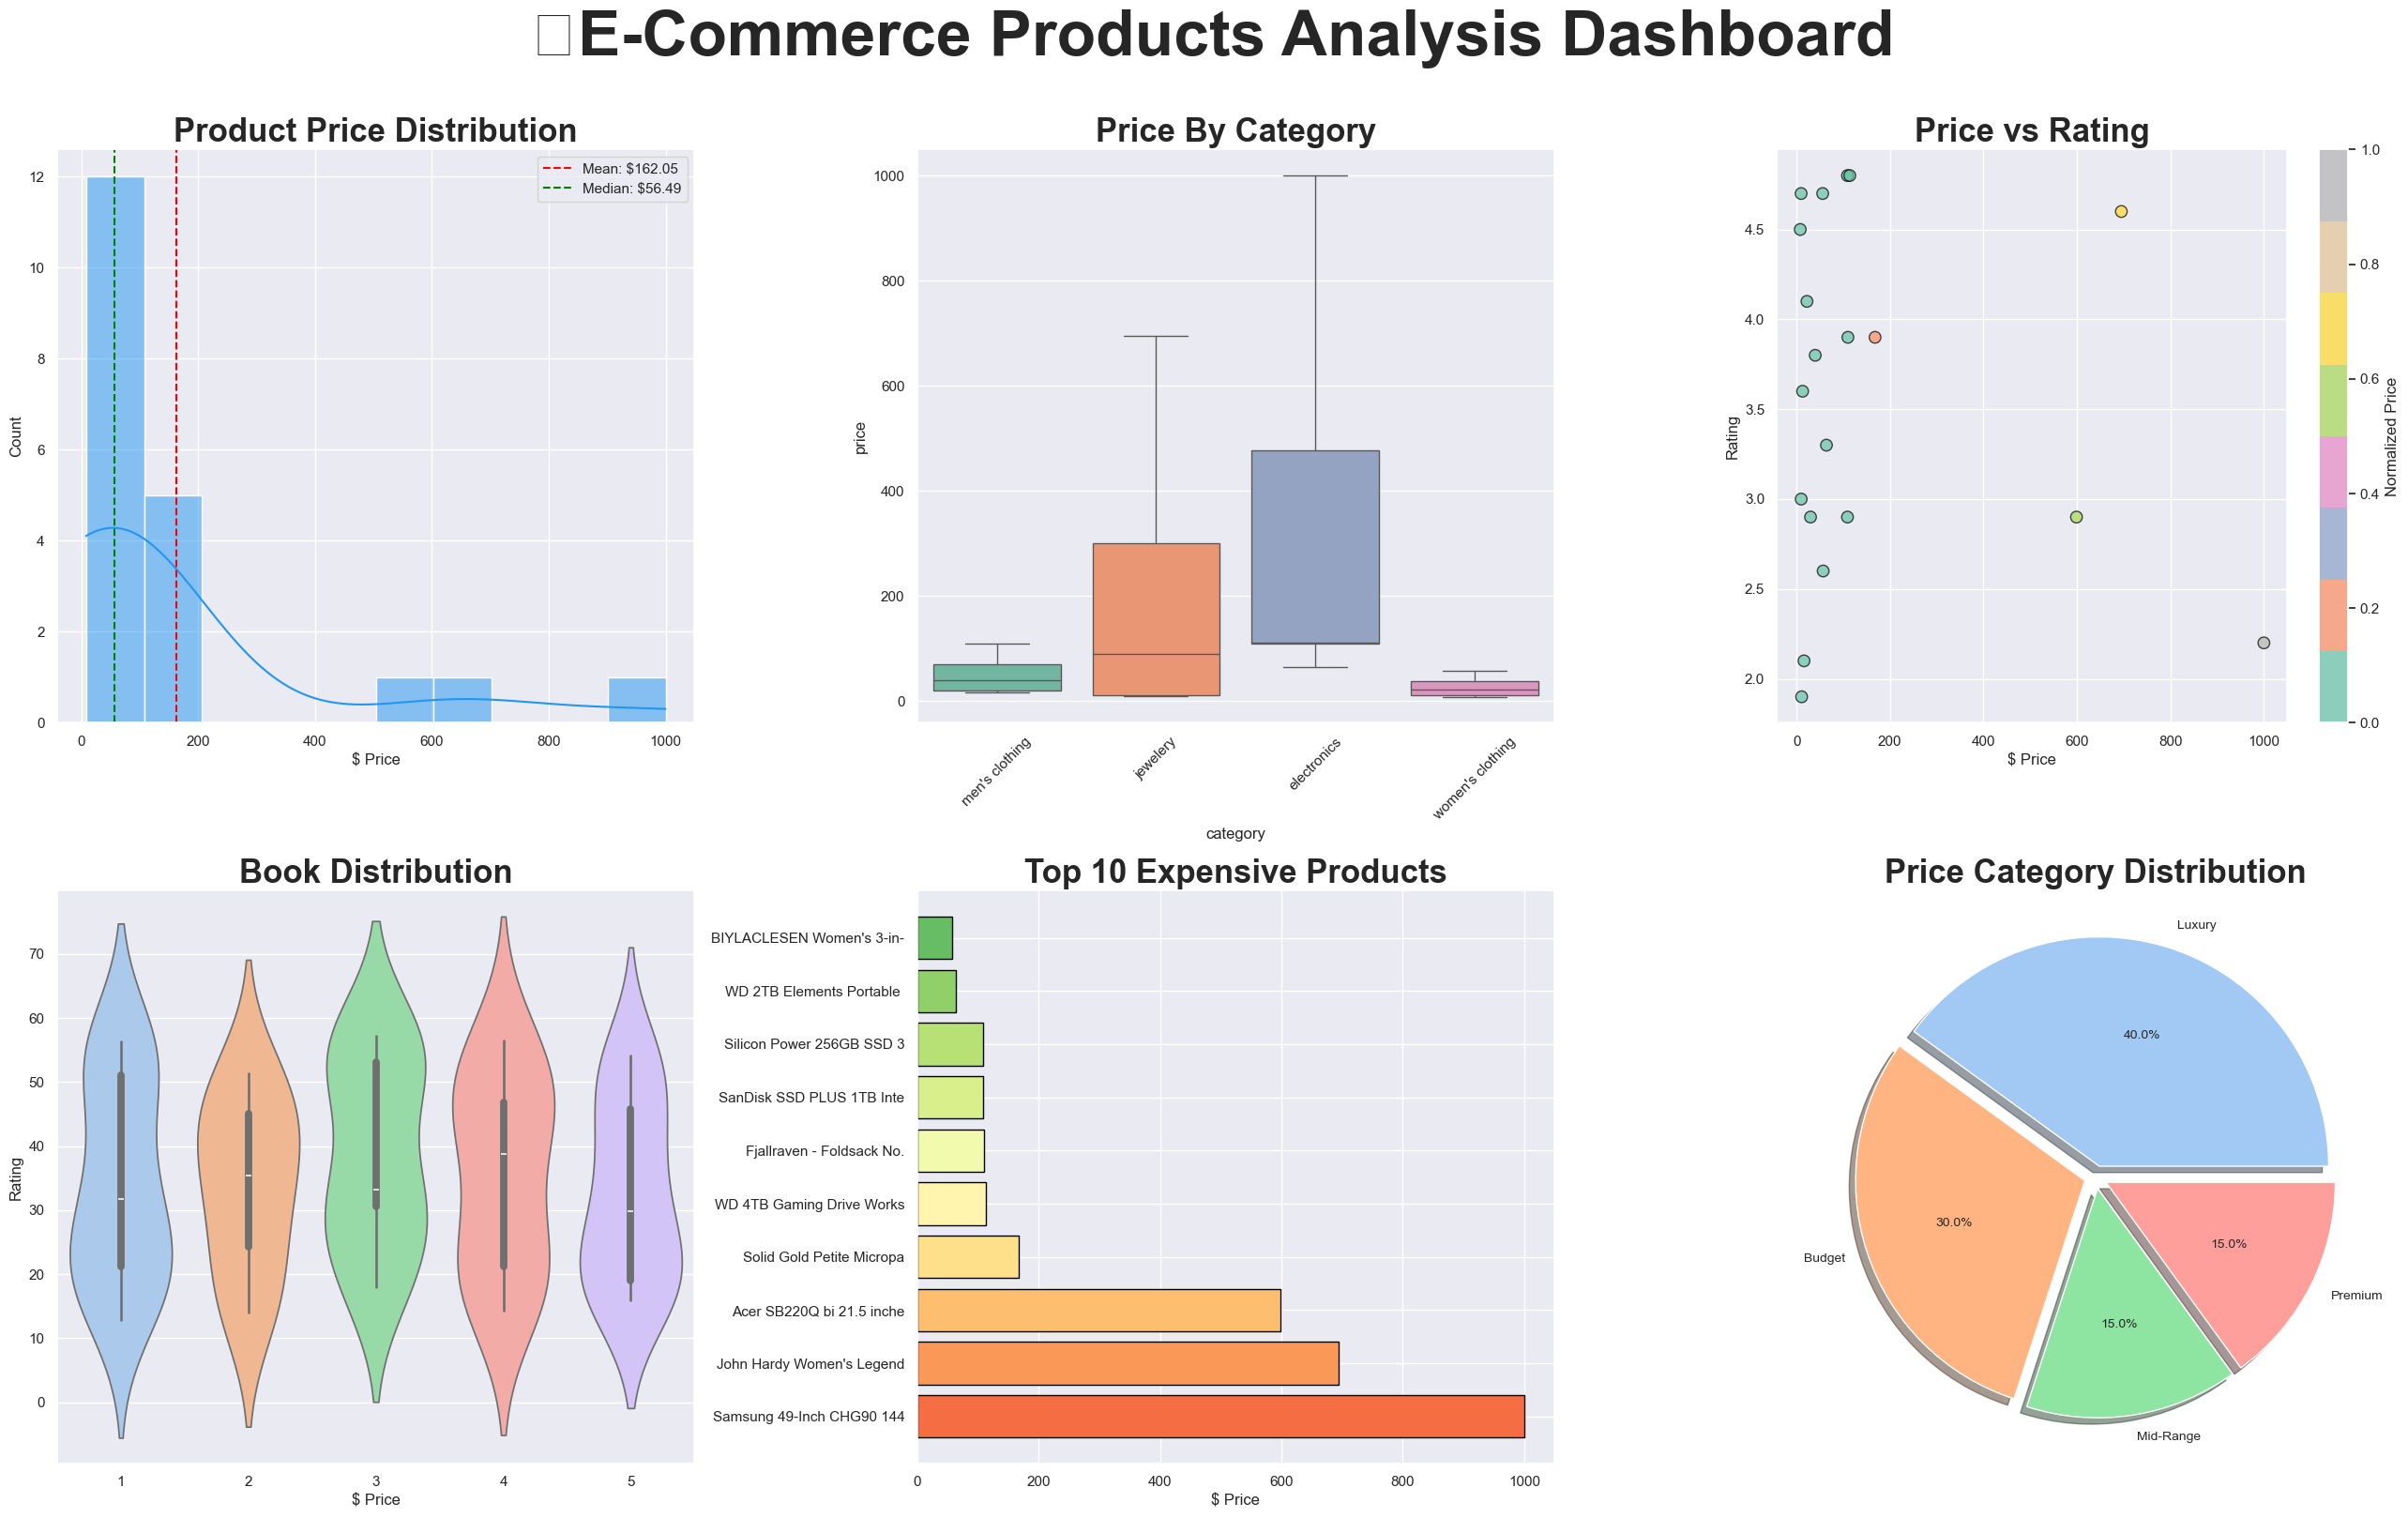

In [29]:
if __name__ == "__main__":

    products = scrape_fake_store_api()
    books = scrape_books_fakestoreapi()

    product_df, stats = process_products_data(products)
    book_df = process_book_data(books)

    create_visualization(product_df, book_df, stats)